**Name : Rohit Nepali**

**Group : L5CG19**

**Std Id :2408301**

array([[156, 157, 160, ..., 152, 152, 152],
       [156, 157, 159, ..., 152, 152, 152],
       [158, 157, 156, ..., 152, 152, 152],
       ...,
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111]], dtype=uint8)
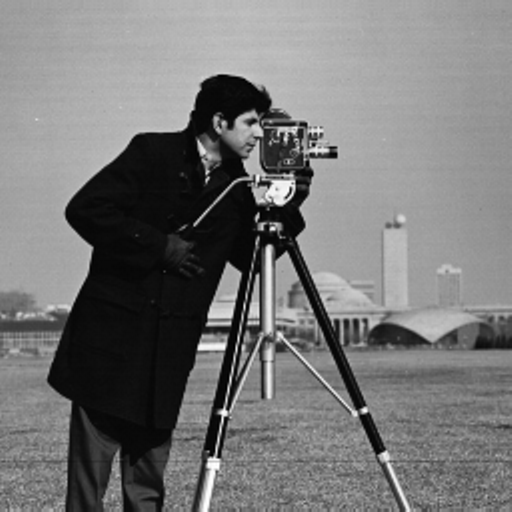

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the image
image_colored = Image.open("/content/drive/MyDrive/2026 - 6CS012 - AI and Machine Learning Materials/Week - 1 - Introduction to Linear Algebra and Derivatives for Deep Learning/cameraman.png")
image = np.array(image_colored)

display(image)

## Exercise 1: Basic Operations (Grayscale)

### Subtask:
Perform basic image manipulations on the grayscale image including cropping, channel analysis, and pixel modification using NumPy.


**Reasoning**:
I will perform the requested image manipulations on the grayscale image, including verifying its shape, cropping, demonstrating channel representation, and modifying a specific pixel region to the constant value of 210.



Original image shape: (512, 512)


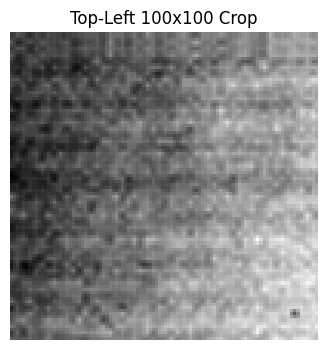

Simulated RGB shape from grayscale: (512, 512, 3)


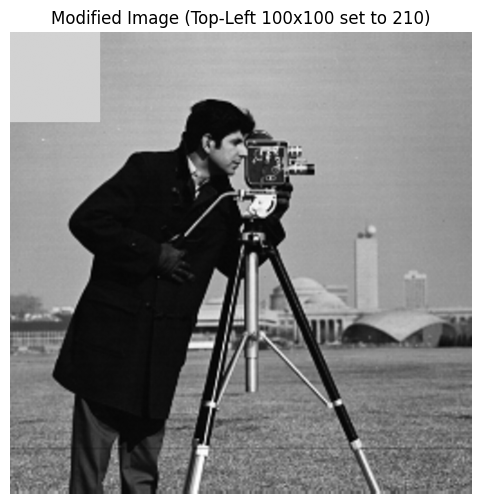

In [31]:
# 1. Verify shape and ensure grayscale
print(f"Original image shape: {image.shape}")
# If it were RGB, we'd convert, but based on kernel state it's already 2D (H, W)
if len(image.shape) == 3:
    # Fallback just in case: Convert to grayscale using luminosity formula
    image_gs = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
else:
    image_gs = image

# 2. Extract and display top-left 100x100 corner
top_left_crop = image_gs[:100, :100]
plt.figure(figsize=(4,4))
plt.imshow(top_left_crop, cmap='gray')
plt.title('Top-Left 100x100 Crop')
plt.axis('off')
plt.show()

# 3. Demonstrate channel representation
# Stacking the same grayscale image 3 times to simulate RGB
simulated_rgb = np.stack([image_gs, image_gs, image_gs], axis=-1)
print(f"Simulated RGB shape from grayscale: {simulated_rgb.shape}")

# 4 & 5. Create copy and modify top-left 100x100 to 210
modified_image = image_gs.copy()
modified_image[:100, :100] = 210

# 6. Display the modified image
plt.figure(figsize=(6,6))
plt.imshow(modified_image, cmap='gray')
plt.title('Modified Image (Top-Left 100x100 set to 210)')
plt.axis('off')
plt.show()

## Exercise 2: Grayscale and Thresholding

### Subtask:
Extract a center section, apply a binary threshold, rotate the image, and convert it to a pseudo-RGB format.


**Reasoning**:
I will perform the image processing steps: extracting the center, thresholding, rotating, and converting to pseudo-RGB as specified.



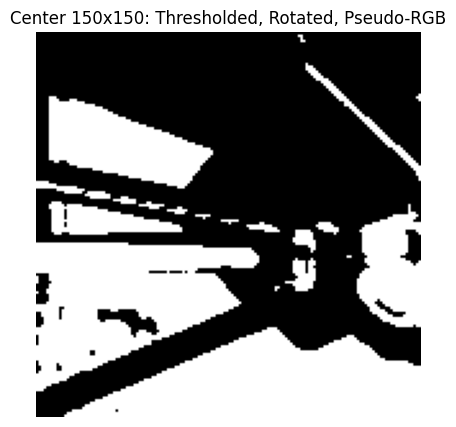

Pseudo-RGB shape: (150, 150, 3)


In [32]:
# 1. Extract a 150x150 pixel center section
h, w = image_gs.shape
center_h, center_w = h // 2, w // 2
start_h, end_h = center_h - 75, center_h + 75
start_w, end_w = center_w - 75, center_w + 75
center_section = image_gs[start_h:end_h, start_w:end_w]

# 2. Apply binary threshold
# Values < 100 to 0, others to 255
thresholded = np.where(center_section < 100, 0, 255).astype(np.uint8)

# 3. Rotate 90 degrees clockwise
# np.rot90 rotates counter-clockwise by default, k=-1 or k=3 is clockwise
rotated_image = np.rot90(thresholded, k=-1)

# 4. Convert to pseudo-RGB by stacking
pseudo_rgb = np.stack([rotated_image, rotated_image, rotated_image], axis=-1)

# 5. Display the result
plt.figure(figsize=(5,5))
plt.imshow(pseudo_rgb)
plt.title('Center 150x150: Thresholded, Rotated, Pseudo-RGB')
plt.axis('off')
plt.show()

print(f'Pseudo-RGB shape: {pseudo_rgb.shape}')

## PCA: Data Preparation

### Subtask:
Standardize the grayscale data by centering it and computing the covariance matrix from scratch.


**Reasoning**:
I will prepare the grayscale image for PCA by normalizing the pixel values, centering the data by subtracting the mean, and then calculating the covariance matrix from scratch using matrix multiplication as instructed.



In [33]:
# 1. Convert grayscale image to float and normalize to [0, 1]
image_float = image_gs.astype(np.float64) / 255.0

# 2. Calculate the mean value for each row (assuming each row is a feature/dimension for PCA)
# For a 512x512 image, this gives a mean vector of size 512
mean_vec = np.mean(image_float, axis=1, keepdims=True)

# 3. Center the data by subtracting the mean from each row
centered_data = image_float - mean_vec

# 4. Compute the covariance matrix from scratch
# Formula: (X * X_T) / (N - 1) where X is centered data
# N is the number of samples (columns in this case, which is 512)
n_samples = centered_data.shape[1]
cov_matrix = np.dot(centered_data, centered_data.T) / (n_samples - 1)

# 5. Verify and print results
print(f"Centered data shape: {centered_data.shape}")
print(f"Covariance matrix shape: {cov_matrix.shape}")
print("Sample of covariance matrix (top-left 3x3):")
print(cov_matrix[:3, :3])

Centered data shape: (512, 512)
Covariance matrix shape: (512, 512)
Sample of covariance matrix (top-left 3x3):
[[0.00162237 0.00161287 0.00154867]
 [0.00161287 0.00160509 0.00154555]
 [0.00154867 0.00154555 0.00151812]]


## PCA: Eigen Decomposition

### Subtask:
Perform eigen-decomposition on the covariance matrix, sort components, and plot cumulative explained variance.


**Reasoning**:
I will perform eigen-decomposition on the covariance matrix, sort the eigenvalues and eigenvectors in descending order, calculate the explained variance, and plot the cumulative explained variance with a threshold line.



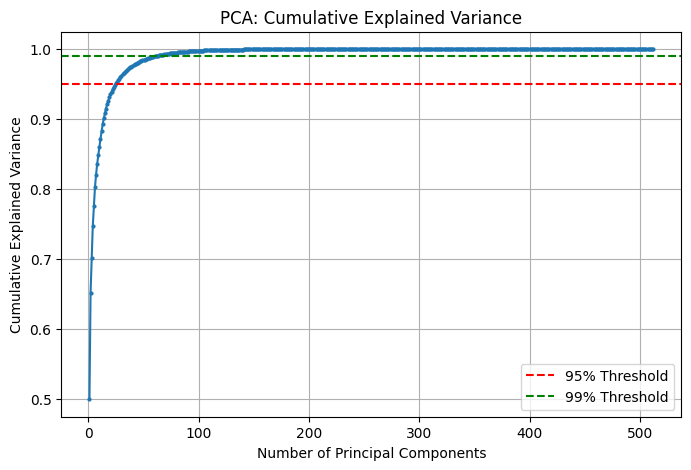

Number of components to capture 95% variance: 25


In [34]:
# 1. Compute eigenvalues and eigenvectors using eigh (optimized for symmetric matrices)
eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)

# 2. Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

# 3. Calculate individual explained variance
explained_variance = eigen_vals / np.sum(eigen_vals)

# 4. Compute cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# 5. Plot the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', markersize=2)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')

# 6. Add a horizontal line at 95% and 99% thresholds
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Threshold')

plt.grid(True)
plt.legend()
plt.show()

# Identify components for 95% variance
n_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f'Number of components to capture 95% variance: {n_95}')

## PCA: Reconstruction Experiments

### Subtask:
Reconstruct the image using four different 'k' values (5, 20, 50, 100) and compare the results visually to evaluate compression fidelity.


**Reasoning**:
I will perform the image reconstruction experiment using PCA with k values of 5, 20, 50, and 100. I will project the centered data onto the top 'k' eigenvectors, reconstruct the image by adding the mean back, and display the results alongside the original image for comparison.



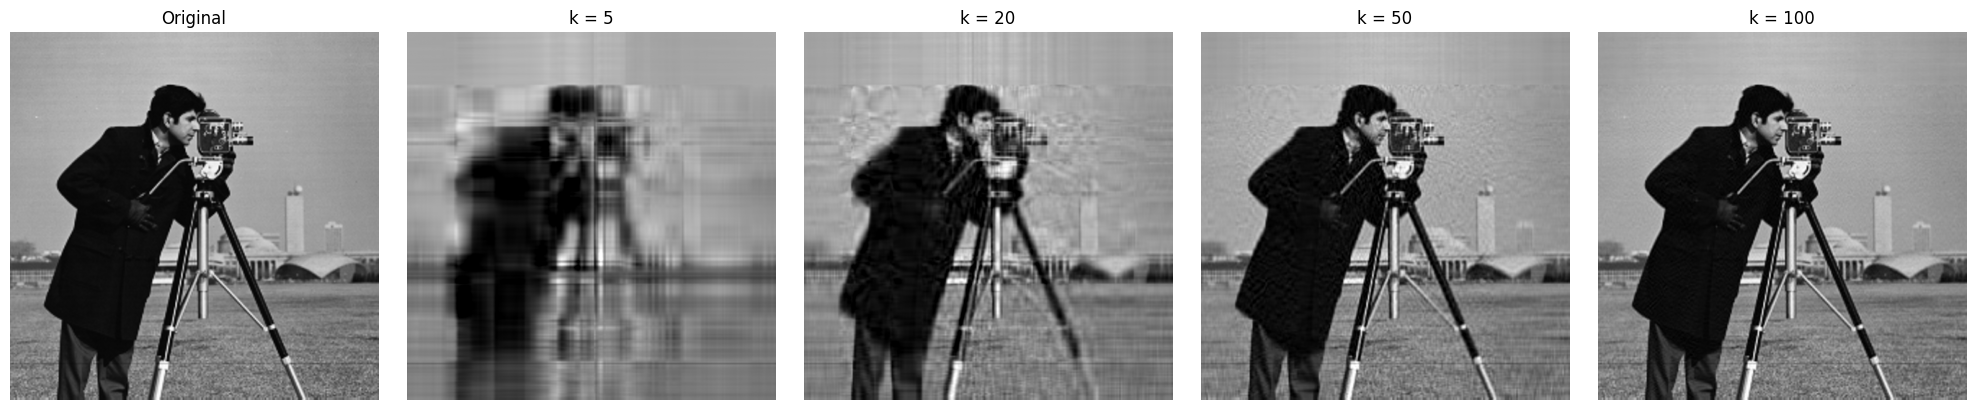

In [35]:
# 1. Define 'k' values
k_values = [5, 20, 50, 100]

# 2. Setup plotting figure
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Display Original
axes[0].imshow(image_float, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# 3. Perform reconstruction for each k
for i, k in enumerate(k_values):
    # a. Select top k eigenvectors
    U_k = eigen_vecs[:, :k]

    # b. Project data to scores (centered_data * U_k)
    # Note: Using dot product for projection
    scores = np.dot(centered_data.T, U_k)

    # c. Reconstruct centered data (scores * U_k.T)
    reconstructed_centered = np.dot(scores, U_k.T).T

    # d. Add the mean vector back
    reconstructed_img = reconstructed_centered + mean_vec

    # e. Clip values to [0, 1] for valid image representation
    reconstructed_img = np.clip(reconstructed_img, 0, 1)

    # 4. Display reconstructed image
    axes[i+1].imshow(reconstructed_img, cmap='gray')
    axes[i+1].set_title(f'k = {k}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a final evaluation of the image processing results and the PCA compression fidelity.


## Summary:

### Q&A

**What was the original image size and how was it modified in the basic operations?**
The original image was a grayscale array of $512 \times 512$ pixels. In the first task, the top-left $100 \times 100$ corner was modified by setting all pixel values to a constant intensity of $210$ (light gray).

**How many principal components are required to retain 95% of the image's variance?**
Based on the cumulative explained variance analysis, only **25 principal components** are needed to capture 95% of the information in the cameraman image.

**How did varying the number of principal components ($k$) affect the image reconstruction?**
At $k=5$, the image was highly blurred, showing only coarse shapes. Clarity improved significantly at $k=20$ and $k=50$. By $k=100$, the reconstructed image was visually almost identical to the original, representing a significant reduction from the original 512 dimensions while maintaining high fidelity.

### Data Analysis Key Findings

*   **Grayscale Properties**: Verification confirmed the image is a single-channel 2D array. A "pseudo-RGB" version was created by stacking this array three times, resulting in a $(H, W, 3)$ shape where all channels are identical.
*   **Thresholding and Geometry**: Applying a binary threshold of $100$ successfully isolated the subject from the background in a $150 \times 150$ center crop, which was then rotated $90^{\circ}$ clockwise.
*   **PCA Efficiency**: The "elbow" in the cumulative variance plot indicates that the majority of image data is redundant. Capturing 99% of the variance requires significantly fewer than the original 512 dimensions.
*   **Reconstruction Fidelity**: PCA reconstruction demonstrated a clear trade-off: lower $k$ values ($k=5$) provide high compression but lose detail, while higher $k$ values ($k=100$) provide excellent detail retention with moderate compression.

### Insights or Next Steps

*   **Optimal Compression**: For practical applications where near-perfect reconstruction is required, $k=100$ is a suitable target; however, for tasks like object recognition, $k=25$ (95% variance) might be sufficient to reduce computational load.
*   **Preprocessing for ML**: The thresholded and centered data produced in these steps serve as an ideal starting point for training edge detection models or simple neural network classifiers.
